# Anndata and objectives of this notebook  

This notebook aims to highlight usages of **Anndata** for microbiome-metabolome analyses. Core advantages of **Anndata** for multiomics analyses are: 

- unified objects to manipulate and store results from data manipulations (filtering, normalisations, etc...) to standard statistical models (PCA, PCoA, differential analyses, etc...).
- Anndata is supported by standard tools in the omics field (pylimma, pyDESeq2, etc...)
- Anndata allows workflow tracking, critical for result reproducibility and transparency.

Data use here are real microbiome-metabolome datasets from the impact of gastrectomy on microbial and metabolomics compositions: 10.1136/gutjnl-2019-319188. 

Functions are provided to manipulate and update **Anndata** objects, feel free to use them for your own usage.  
See https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html for detailled presentations of **Anndata**.

In [314]:
from skbio.stats import composition
from skbio.stats.distance import permanova, DistanceMatrix
from skbio.diversity import alpha_diversity
from scipy.spatial.distance import pdist, squareform
from skbio.stats.ordination import pcoa
from sklearn.decomposition import PCA
import anndata
import pandas as pd 
import numpy as np 
from plotnine import *
import seaborn as sns 
import pylimma as pm #for differential analysis of metabolites 
from statsmodels.formula.api import ols

# Functions to manipulate and update Anndata objects

In [ ]:
def update_Anndata_with_PCA(Anndata, layer=None, n_components = 2):
    """
    This function runs a PCA on a Anndata object and updates the uns key with corresponding coordinates

    @param Anndata: a Anndata object 
    @param layer: a str corresponding to the layer on which the PCA is ran on, default is None
    @param n_components: an int corresponding to the number of components to extract from the PCA, default is 2

    @return an updated Anndata object with the PCA coordinates
    """
    pca = PCA(n_components = n_components)
    
    if layer is None:
        Anndata.uns["PC coordinates"] = pca.fit_transform(Anndata.X)
    elif layer is not None:
        Anndata.uns["PC coordinates"] = pca.fit_transform(Anndata.layers[layer])

    return(Anndata)

def update_Anndata_with_alpha_diversity(Anndata,  layer=None, metric="shannon"):
    """
    This function computes the alpha diversity on a Anndata object and updates the uns key with the corresponding values

    @param Anndata: a Anndata object 
    @param layer: a str corresponding to the layer on which the PCA is ran on, default is None
    @param metric: a str corresponding to the type of diversity to be computed

    @return an updated Anndata object with the corresponding alpha diversity
    """
    if layer is None: 
        Anndata.uns["alpha diversity"] = alpha_diversity(metric, Anndata.X)
    elif layer is not None:
        Anndata.uns["alpha diversity"] = alpha_diversity(metric, Anndata.layers[layer])
    return(Anndata)

def update_Anndata_with_beta_diversity(Anndata,  layer=None, metric="euclidean"):
    """
    This function computes the beta diversity on a Anndata object and updates the uns key with the corresponding values

    @param Anndata: a Anndata object 
    @param layer: a str corresponding to the layer on which the PCA is ran on, default is None
    @param metric: a str corresponding to the type of diversity to be computed

    @return an updated Anndata object with the corresponding beta diversity
    """
    if layer is None: 
        Anndata.uns["beta diversity"] = squareform(pdist(Anndata.X, metric=metric))
    elif layer is not None:
        Anndata.uns["beta diversity"] = squareform(pdist(Anndata.layers[layer], metric=metric))
    return(Anndata)

def update_Anndata_with_PCoA(Anndata, layer=None, n_components = 2, metric="euclidean"):
    """
    This function runs a PCoA on a Anndata object and updates the uns key with corresponding coordinates

    @param Anndata: a Anndata object 
    @param layer: a str corresponding to the layer on which the PCoA is ran on, default is None
    @param n_components: an int corresponding to the number of components to extract from the PCoA, default is 2

    @return an updated Anndata object with the PCoA coordinates
    """
        
    Anndata = update_Anndata_with_beta_diversity(Anndata, layer=layer, metric=metric)
    Anndata.uns["PCoA coordinates"] = pcoa(Anndata.uns["beta diversity"], dimensions=n_components).samples

    return(Anndata)

def updata_Anndata_with_ancombc(Anndata, formula): 

    """
    This function runs ancombc on a Anndata object and updates the uns key with the corresponding results

    @param Anndata: a Anndata object
    @param formula: a str corresponding to the fixed effects to be included in the model
    """

    species_counts_for_ancombc = pd.DataFrame(Anndata.X, columns=Anndata.var_names, index=Anndata.obs.index)
    results_ancombc = composition.ancombc(table=species_counts_for_ancombc,metadata=Anndata.obs, formula=formula)
    
    results_ancombc["-log10(pvalue)"] = -1*np.log10(results_ancombc["pvalue"])

    Anndata.uns["results_ancombc"] = results_ancombc.reset_index()
    return(Anndata)

In [ ]:
metadata = pd.read_csv("metadata.tsv", header=0, sep="\t")
species_counts = pd.read_csv("species.counts.tsv", header=0, sep="\t")
metabolites = pd.read_csv("mtb.tsv", header=0, sep="\t")

In [ ]:
species_counts.shape

(96, 48244)

In [ ]:
metabolites.shape

(96, 525)

In [ ]:
metadata.shape

(96, 52)

In [ ]:
#Sort values to ensure sample alignment
metadata = metadata.sort_values(by="Sample")
species_counts = species_counts.sort_values(by="Sample")
metabolites = metabolites.sort_values(by="Sample")

print(np.all([x == y for (x,y) in zip(metadata["Sample"], species_counts["Sample"])]))
print(np.all([x == y for (x,y) in zip(metadata["Sample"], metabolites["Sample"])]))

#Samples are aligned with metadata in both microbiome and metabolome datasets 

True
True


In [ ]:
species_counts = species_counts.set_index(keys="Sample")
metabolites = metabolites.set_index(keys="Sample")
metadata = metadata.set_index(keys="Sample")

# Create Anndata Objects for both metagenomics and metabolomics datasets 

In [ ]:
adata_species_counts = anndata.AnnData(X=species_counts, obs=metadata, var=species_counts.columns.to_frame())

In [ ]:
adata_metabolites = anndata.AnnData(X=metabolites, obs=metadata, var=metabolites.columns.to_frame())

C:\Users\MRC\AppData\Local\Temp\ipykernel_14832\3791322434.py:1: UserWarning: X converted to numpy array with dtype float64


### Data filtering and normalisation

In [ ]:
print("Number of metabolites with missing values less than half the number of samples: {0}".format(np.sum(np.sum(adata_metabolites.X == 0, axis=0) < 48)))
print("Number of species with missing values less than half the number of samples: {0}".format(np.sum(np.sum(adata_species_counts.X == 0, axis=0) < 48)))

Number of metabolites with missing values less than half the number of samples: 143
Number of species with missing values less than half the number of samples: 6325


In [ ]:
# Whole Anndata objects can be directly updated to filter out features with missing values in more than half of the samples.
bdata_metabolites = adata_metabolites[:,np.sum(adata_metabolites.X == 0, axis=0) < 48]
bdata_species_counts = adata_species_counts[:,np.sum(adata_species_counts.X == 0, axis=0) < 48]

In [ ]:
#Add pseudo-counts of 1 for avoiding numerical issues of log-based transformations 
bdata_metabolites.X = bdata_metabolites.X + 1
bdata_species_counts.X = bdata_species_counts.X +1

C:\Users\MRC\AppData\Local\Temp\ipykernel_14832\4005432448.py:2: ImplicitModificationWarning: Setting element `.X` of view, initializing view as actual.
C:\Users\MRC\AppData\Local\Temp\ipykernel_14832\4005432448.py:3: ImplicitModificationWarning: Setting element `.X` of view, initializing view as actual.


In [ ]:
#Create a layer with log2 transformation of metabolites 
bdata_metabolites.layers["Log2"] = np.log2(bdata_metabolites.X)

#Create an additional layer with median normalized signal of log2 transformed metabolites
bdata_metabolites.layers["normalized Log2"] = pm.normalize_median_values(bdata_metabolites.layers["Log2"].T).T

## Visual inspection of the impact of normalisations over sample comparability

<Axes: >

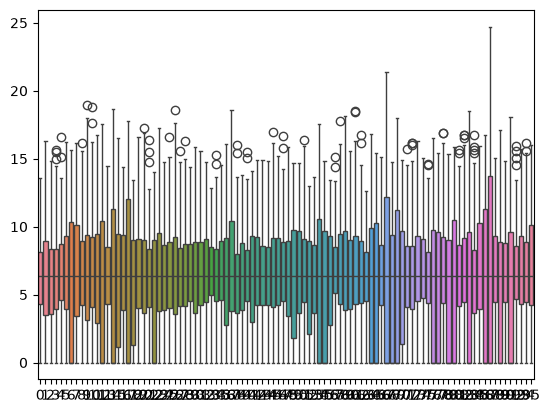

In [ ]:
sns.boxplot(bdata_metabolites.layers["normalized Log2"].T)

In [ ]:
#Create a layer with clr transformation of species for accounting for compositionality
bdata_species_counts.layers["clr"] = composition.clr(bdata_species_counts.X)

<Axes: >

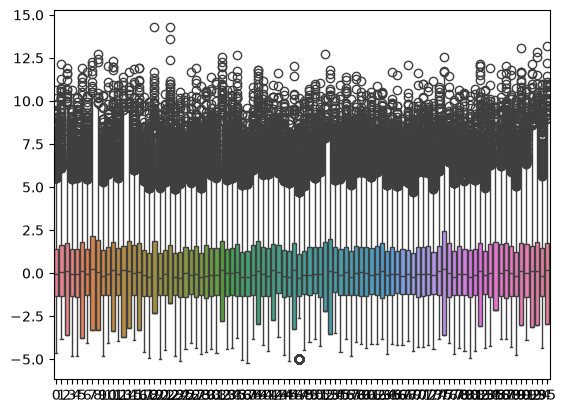

In [ ]:
sns.boxplot(bdata_species_counts.layers["clr"].T)

Both normalisations for microbiome and metabolome signals offer good sample comparability accounting for differences in detection sensitivity or sequencing depth. We will stuck on median normalisation over log2 signals for metabolomics and clr for metagenomics for global analyses. 

## Metabolome

### Whole Metabolome diversity between Study Groups using PCA

In [ ]:
#Run PCA on metabolomics profiles
bdata_metabolites = update_Anndata_with_PCA(bdata_metabolites, layer="normalized Log2")

In [ ]:
dataframe_for_PCA_metabolites = pd.DataFrame(bdata_metabolites.uns["PC coordinates"], columns=["PC1","PC2"])
dataframe_for_PCA_metabolites["Sample"] = metadata.index
dataframe_for_PCA_metabolites = dataframe_for_PCA_metabolites.set_index("Sample")
dataframe_for_PCA_metabolites = pd.concat([dataframe_for_PCA_metabolites, metadata["Study.Group"].to_frame()], axis=1)

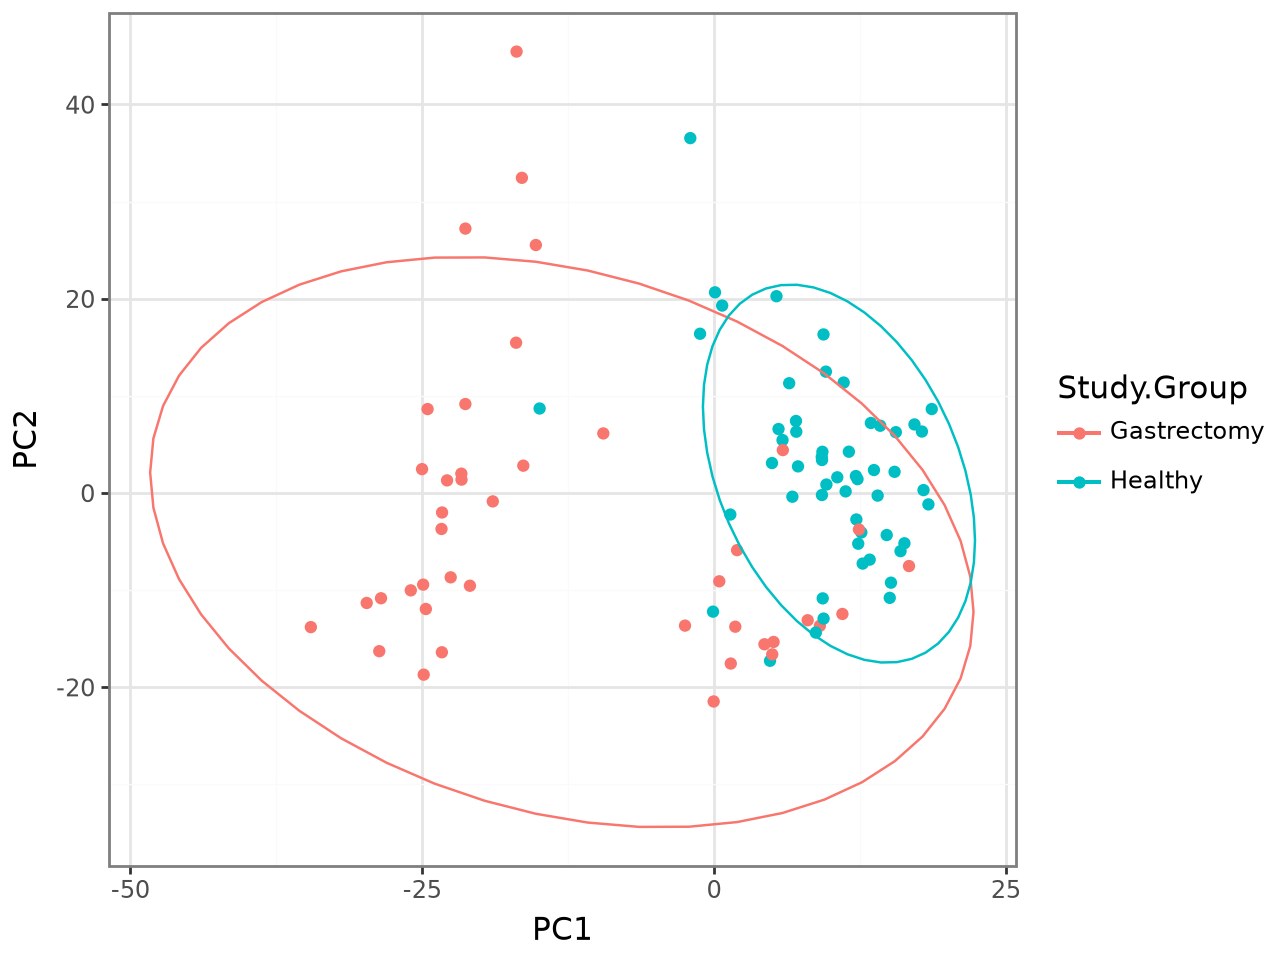

In [ ]:
ggplot(dataframe_for_PCA_metabolites, aes('PC1', 'PC2', color='Study.Group'))+geom_point()+stat_ellipse()+theme_bw()

The two first principal components explain 33% of the total metabolome variance.  
Gastrectomy seems to induce differences at the whole metabolome levels with a higher variability in the Gastrectomy group.

### Differential analysis using pylimma  

Compared to **skbio**, **pylimma** is able to work directly with an **Anndata** object without the need to manually modify the object. Here we run **pylimma** to find differential metabolites between study groups. Other important module features will also be highlighted as *top_table*. Results of **pylimma** are stored into the uns of the **Anndata** object.  

Using basic features of **pylimma** we find 89 metabolites which significantly vary between the two conditions. 

In [ ]:
bdata_metabolites.obs = bdata_metabolites.obs[["Age","Study.Group"]]
bdata_metabolites.obs = bdata_metabolites.obs.rename(columns={"Study.Group":"Study_Group"})

In [ ]:
#In the easiest scenario (with no complex contrasts), pylimma 1) fits a linear model 2) moderate the statistic using empirical bayesian procedure
pm.lm_fit(bdata_metabolites, design="Study_Group",layer="normalized Log2")
pm.e_bayes(bdata_metabolites)

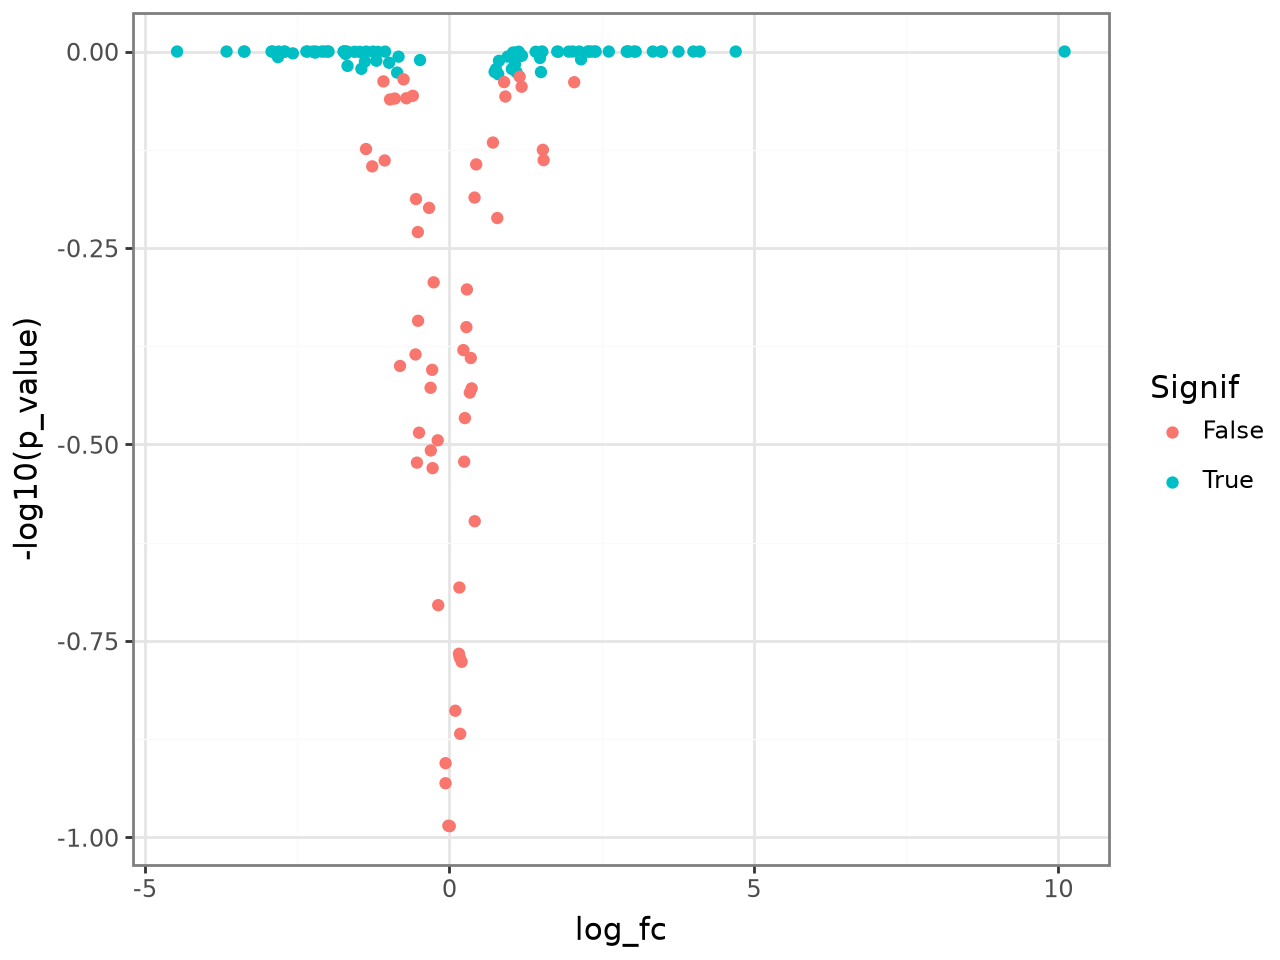

In [ ]:
#top table can be extracted 
toptable_metabolites_studygroup = pm.top_table(bdata_metabolites, coef=1, number=bdata_metabolites.X.shape[1])
toptable_metabolites_studygroup["-log10(p_value)"] = -1*toptable_metabolites_studygroup["p_value"]
toptable_metabolites_studygroup["Signif"] = toptable_metabolites_studygroup["adj_p_value"]<=0.05

ggplot(toptable_metabolites_studygroup, aes(x="log_fc", y="-log10(p_value)", color="Signif")) + geom_point()+ theme_bw()

In [ ]:
toptable_metabolites_studygroup.loc[:, "Signif"].value_counts()

Signif
True     89
False    54
Name: count, dtype: int64

## Microbiome 

### Intra-sample diversity using shannon entropy

In [ ]:
bdata_species_counts = update_Anndata_with_alpha_diversity(bdata_species_counts, layer=None, metric="shannon")

In [ ]:
dataframe_for_alpha_diversity_species = pd.DataFrame(bdata_species_counts.uns["alpha diversity"], columns=["alpha_diversity"])
dataframe_for_alpha_diversity_species["Sample"] = metadata.index
dataframe_for_alpha_diversity_species = dataframe_for_alpha_diversity_species.set_index("Sample")
dataframe_for_alpha_diversity_species = pd.concat([dataframe_for_alpha_diversity_species, metadata["Study.Group"].to_frame()], axis=1)
dataframe_for_alpha_diversity_species = dataframe_for_alpha_diversity_species.rename(columns={"Study.Group":"Study_Group"})

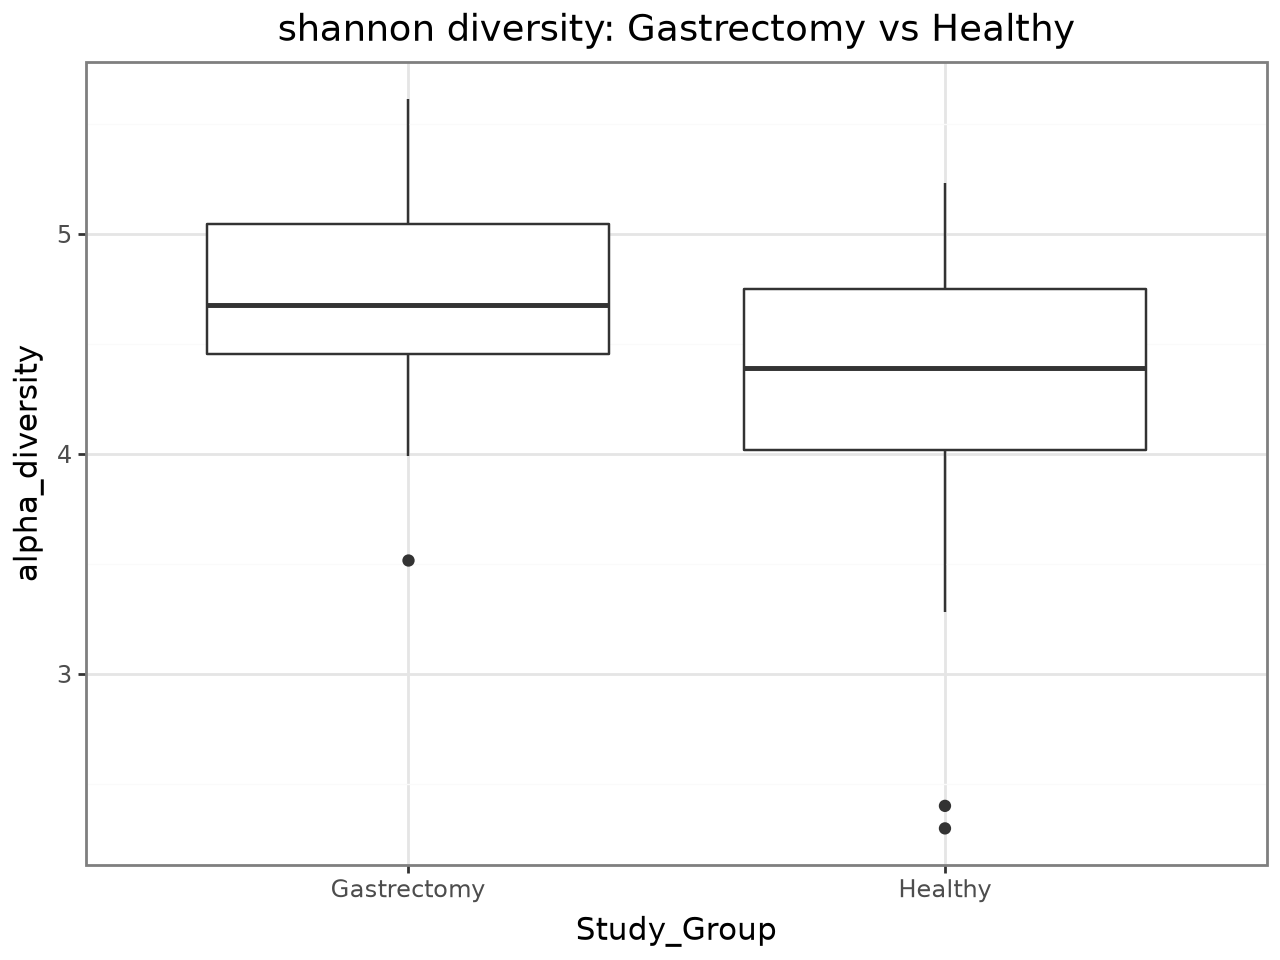

In [ ]:
ggplot(dataframe_for_alpha_diversity_species,aes(x="Study_Group", y="alpha_diversity")) + geom_boxplot()+theme_bw()+ggtitle("shannon diversity: Gastrectomy vs Healthy")

Intra-sample diversity is higher in the Gastrectomy group compared to healthy individuals. This result could be explained by less dominant benefical species in the gastrectomy group. However a deeper investigation is required for confirming this hypotheis.   

In [ ]:
ols_alpha_diversity_groups = ols("alpha_diversity ~ Study_Group",dataframe_for_alpha_diversity_species)
res = ols_alpha_diversity_groups.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:        alpha_diversity   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     11.24
Date:                Sun, 16 Aug 2026   Prob (F-statistic):            0.00115
Time:                        21:16:41   Log-Likelihood:                -79.360
No. Observations:                  96   AIC:                             162.7
Df Residuals:                      94   BIC:                             167.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  4

Linear regression confirms visual inspection using boxplot where intra-sample diversity decreases by 0.38 units in healthy individuals compared to individuals having gastrectomy. This result is totally aligned with those presented in the original paper. 

### Whole Microbiome diversity between Study Groups using PcoA

In [ ]:
bdata_species_counts = update_Anndata_with_PCoA(bdata_species_counts, layer="clr")

In [ ]:
dataframe_for_beta_diversity_species = bdata_species_counts.uns["PCoA coordinates"]
dataframe_for_beta_diversity_species["Sample"] = metadata.index
dataframe_for_beta_diversity_species = dataframe_for_beta_diversity_species.set_index("Sample")
dataframe_for_beta_diversity_species = pd.concat([dataframe_for_beta_diversity_species, metadata["Study.Group"].to_frame()], axis=1)
dataframe_for_beta_diversity_species = dataframe_for_beta_diversity_species.rename(columns={"Study.Group":"Study_Group"})

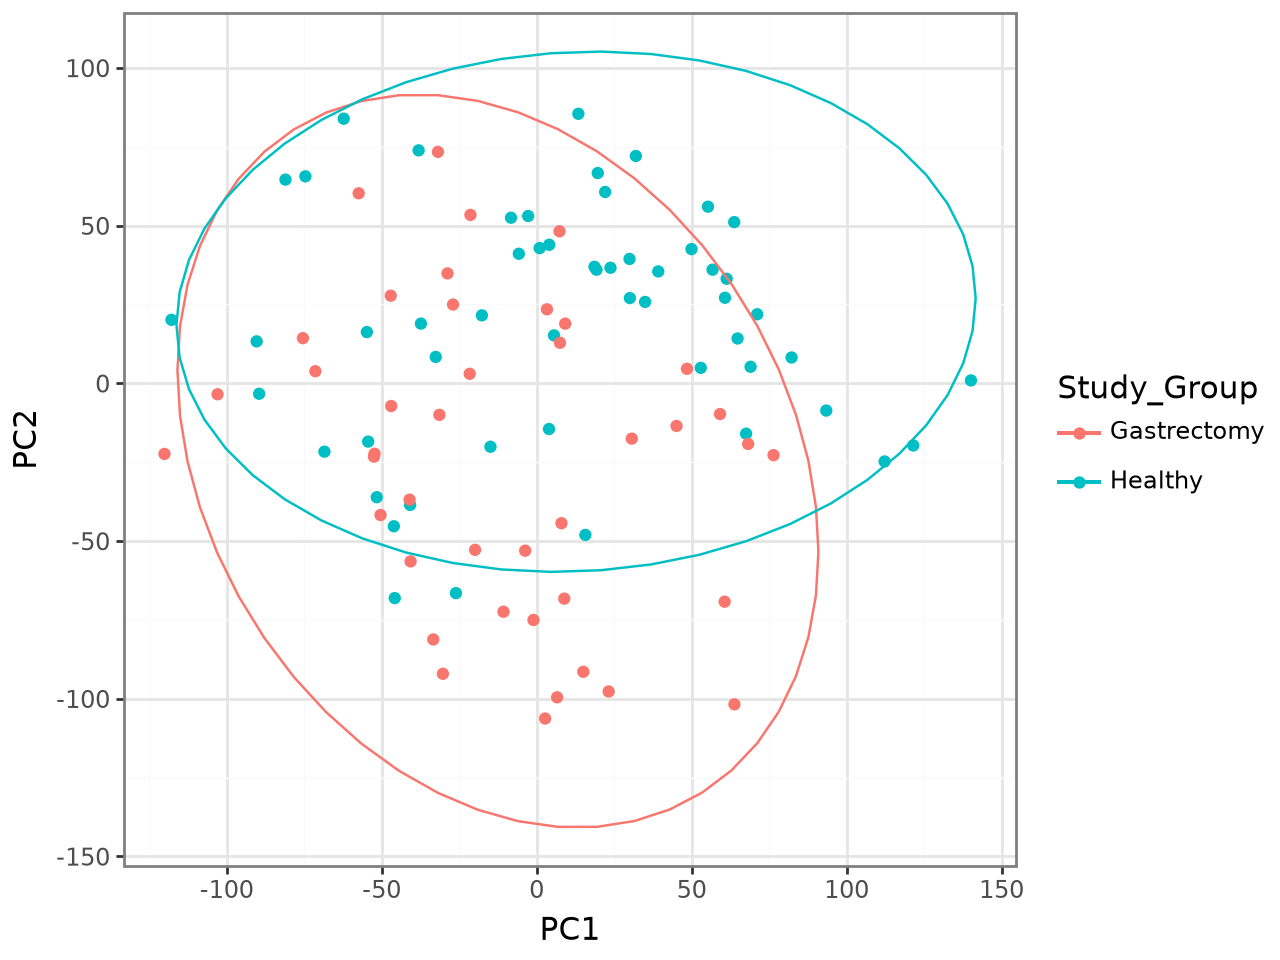

In [ ]:
ggplot(dataframe_for_beta_diversity_species, aes('PC1', 'PC2', color='Study_Group'))+geom_point()+stat_ellipse()+theme_bw()

### PERMANOVA  

PERMANOVA is implemented in the **skbio** module.

In [ ]:
permanova(DistanceMatrix(bdata_species_counts.uns["beta diversity"], ids=bdata_species_counts.obs.index), bdata_species_counts.obs["Study.Group"])

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      96
number of groups                  2
test statistic             3.791843
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

PERMANOVA highlights a significant association of the study group on the beta diversity suggesting global differences in microbial compositions between the two groups. We can expect differences in microbial abundances in differential analyses.

### Differential abundance analysis using ANCOMBC  

Here we compared the species abundances between the healthy and gastrectomy groups to find differential abundant microbial organisms. Here we use ancombc as implemented in the *composition* module of **skbio**. We generate the corresponding volcano plot and found 102 species which significantly vary between the two conditions. 

In [ ]:
#we only keep the age and study group for easy manipulations
bdata_species_counts.obs = bdata_species_counts.obs[["Study.Group", "Age"]]
#Study group is reformated for formula compatibility
bdata_species_counts.obs = bdata_species_counts.obs.rename(columns={"Study.Group":"Study_Group"})

bdata_species_counts = updata_Anndata_with_ancombc(bdata_species_counts, "Study_Group")

AnnData object with n_obs × n_vars = 96 × 6325
    obs: 'Study_Group', 'Age'
    var: 0
    uns: 'alpha diversity', 'beta diversity', 'PCoA coordinates', 'results_ancombc'
    layers: None (.X), 'clr'

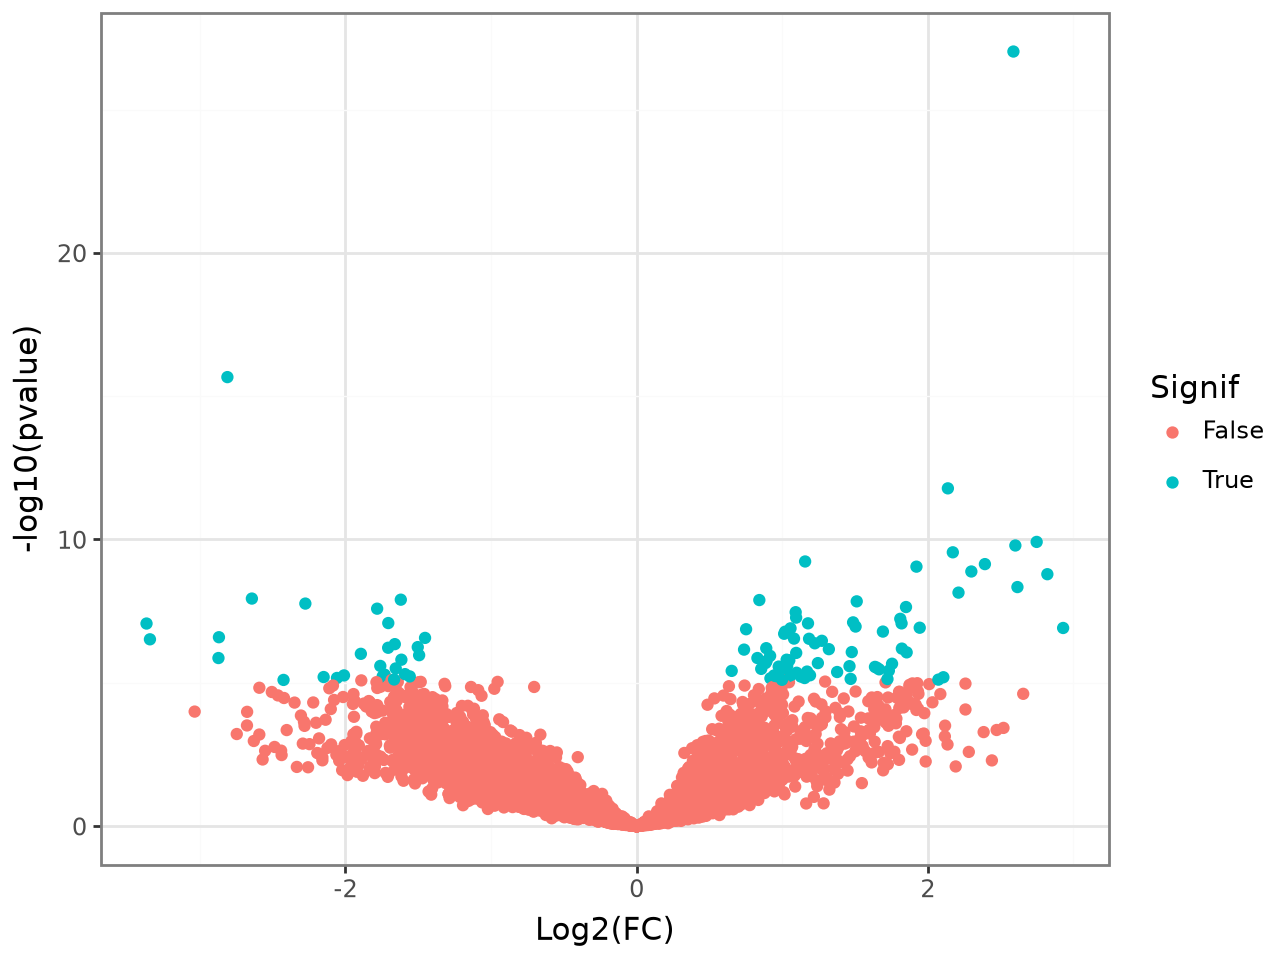

In [ ]:
ggplot(bdata_species_counts.uns["results_ancombc"][
    bdata_species_counts.uns["results_ancombc"]["Covariate"]=="Study_Group[T.Healthy]"], aes(x="Log2(FC)", y="-log10(pvalue)", color="Signif"))+geom_point()+theme_bw()

In [ ]:
bdata_species_counts.uns["results_ancombc"].loc[
    (bdata_species_counts.uns["results_ancombc"]["Covariate"]=="Study_Group[T.Healthy]"), "Signif"].value_counts()

Signif
False    6223
True      102
Name: count, dtype: Int64

# Conclusions 

In this first notebook we cover the advantages of using **Anndata**for common applications for metagenomics and metabolomics datasets, covering data filtering and normalisations to statistical modelling. **Anndata** as for many python modules takes advantages of the interesing programmatic capabilities and can be easily combined with all the python ecosystem. Next notebooks will emphasis more on multi-omics integrations, showing how **Anndata** can be included in multi-omics pipelines.  